In [10]:
# Usa sua função existente
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from src.ColorsAnalysis import *

In [21]:
def processing_data_nc(L_lst, Nt_lst, k_lst, num_colors, dim, type_perc):
    """
    Lê *exclusivamente* os process_names.txt e calcula n_c.
    Mudança: resolução de caminhos é robusta — NÃO formata k/rho; encontra as
    pastas reais (k_* / rho_*) por aproximação numérica.
    """
    import math
    from pathlib import Path

    base_root  = "../Data"
    output_dir = "../Data/bond_percolation/"
    rows = []

    def _find_dir_by_value(parent: Path, prefix: str, target: float, rel_tol=1e-12, abs_tol=1e-15) -> Path | None:
        """Dentro de 'parent', encontra pasta do tipo '{prefix}_*' cujo valor numérico ≈ target."""
        best = None
        for d in parent.glob(f"{prefix}_*"):
            if not d.is_dir():
                continue
            try:
                val = float(d.name.split(f"{prefix}_", 1)[1])
            except Exception:
                continue
            if math.isclose(val, float(target), rel_tol=rel_tol, abs_tol=abs_tol):
                best = d
                break
        return best

    root = Path(base_root)

    for L in L_lst:
        for NT in Nt_lst:
            for k in k_lst:
                # Descobre rhos existentes usando sua função (mantido)
                rho_values = list_rho_values(type_perc, num_colors, dim, L, NT, k, base_root=base_root)

                # Caminho base até NT_{NT}
                base_NT = (
                    root / f"{type_perc}_percolation" /
                    f"num_colors_{num_colors}" / f"dim_{dim}" /
                    f"L_{L}" / "NT_constant" / f"NT_{NT}"
                )
                if not base_NT.exists():
                    continue

                # Resolve k_* real que corresponde a k
                k_dir = _find_dir_by_value(base_NT, "k", k)
                if k_dir is None:
                    # nada com esse k — próximo
                    continue

                for rho in rho_values:
                    # Resolve rho_* real que corresponde a rho dentro do k_dir
                    rho_dir = _find_dir_by_value(k_dir, "rho", rho)
                    if rho_dir is None:
                        continue

                    p = rho_dir / "data" / "process_names.txt"
                    if not p.exists():
                        continue

                    try:
                        df = read_table_auto(p)
                        n_c, n_c_err, N = compute_nc_from_df(df)
                        rows.append({
                            "L": L,
                            "n_colors": num_colors,
                            "NT": NT,
                            "k": float(k),
                            "rho": float(rho),
                            "n_c": n_c,
                            "n_c_err": n_c_err,
                            "Nsamples": N
                        })
                    except Exception as e:
                        print(f"[WARN] Falha em {p}: {e}")

    # saída final (mantida)
    out_dir_path = Path(output_dir)
    out_dir_path.mkdir(parents=True, exist_ok=True)
    out_csv_path = out_dir_path / f"nc_dim_{dim}.csv"

    merged = upsert_summary(out_csv_path, rows)

    print("\nResumo atualizado:")
    print(merged.sort_values(["L","NT","k","rho"]).to_string(index=False))
    print(f"\nArquivo salvo/atualizado: {out_csv_path}")


## 4 COLORS

In [14]:
# ===== PARÂMETROS =====
type_perc = "bond"
num_colors = 4
dim = 2

L_lst  = [512, 1024, 2048, 4096]
Nt_lst = [50, 100, 200, 400]
k_lst  = [4.0e-04, 2.0e-04, 9.0e-05, 5.0e-05]

processing_data_nc(L_lst, Nt_lst, k_lst, num_colors, dim, type_perc)


Resumo atualizado:
   L  n_colors  NT      n_c  n_c_err      rho       k  Nsamples
 512         4  50 2.700650 0.016979 0.001000 0.00040      2001
 512         4  50 2.428786 0.016849 0.007385 0.00040      2001
 512         4  50 2.091954 0.016901 0.013769 0.00040      2001
 512         4  50 1.678161 0.016418 0.020154 0.00040      2001
 512         4  50 1.252874 0.016504 0.026538 0.00040      2001
 512         4  50 0.771614 0.015068 0.032923 0.00040      2001
 512         4  50 0.349825 0.011520 0.039308 0.00040      2001
 512         4  50 0.075962 0.005966 0.045692 0.00040      2001
 512         4  50 0.006997 0.001864 0.052077 0.00040      2001
 512         4  50 0.001499 0.000865 0.058462 0.00040      2001
 512         4  50 0.000000 0.000000 0.064846 0.00040      2001
 512         4  50 0.000000 0.000000 0.071231 0.00040      2001
 512         4  50 0.000000 0.000000 0.077615 0.00040      2001
 512         4  50 0.000000 0.000000 0.084000 0.00040      2001
 512         4  50 0

In [23]:
# ajuste base_root para o caminho real da sua pasta Data
#base_root = "/home/junior/Documents/self_organization_percolation/Data/"

type_perc  = "bond"
num_colors = 4
dim        = 2
L_lst      = [512, 1024, 2048, 4096]
Nt_lst     = [50, 100, 200, 400]
k_lst      = [4.0e-04, 2.0e-04, 9.0e-05, 5.0e-05]

processing_data_nc(L_lst, Nt_lst, k_lst, num_colors, dim, type_perc)



Resumo atualizado:
   L  n_colors  NT      n_c  n_c_err      rho       k  Nsamples
 512         4  50 2.700650 0.016979 0.001000 0.00040      2001
 512         4  50 2.428786 0.016849 0.007385 0.00040      2001
 512         4  50 2.091954 0.016901 0.013769 0.00040      2001
 512         4  50 1.678161 0.016418 0.020154 0.00040      2001
 512         4  50 1.252874 0.016504 0.026538 0.00040      2001
 512         4  50 0.771614 0.015068 0.032923 0.00040      2001
 512         4  50 0.349825 0.011520 0.039308 0.00040      2001
 512         4  50 0.075962 0.005966 0.045692 0.00040      2001
 512         4  50 0.006997 0.001864 0.052077 0.00040      2001
 512         4  50 0.001499 0.000865 0.058462 0.00040      2001
 512         4  50 0.000000 0.000000 0.064846 0.00040      2001
 512         4  50 0.000000 0.000000 0.071231 0.00040      2001
 512         4  50 0.000000 0.000000 0.077615 0.00040      2001
 512         4  50 0.000000 0.000000 0.084000 0.00040      2001
 512         4  50 0

In [24]:
df = pd.read_csv("../Data/bond_percolation/nc_dim_2.csv")

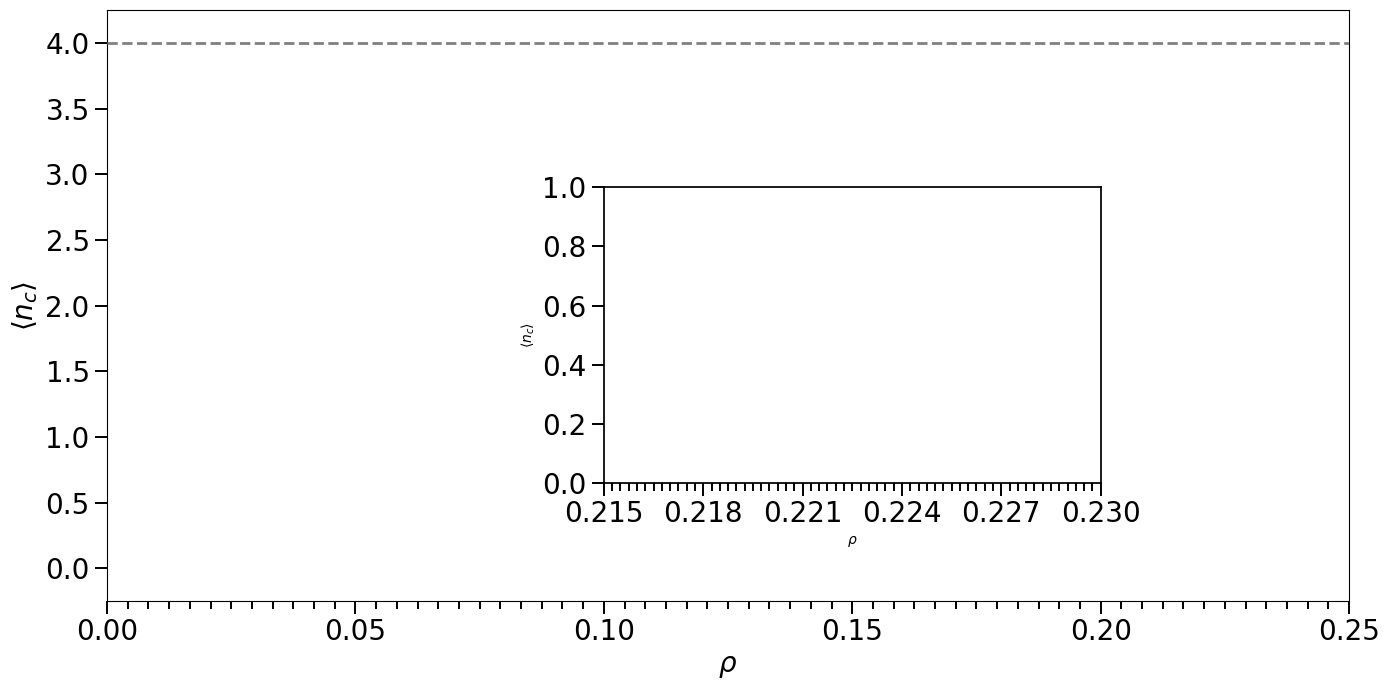

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

# ==== caminho do seu resumo ====
dim = 2
csv_path = f"../Data/bond_percolation/nc_dim_{dim}.csv"

# ==== parâmetros do plot ====
num_colors = 4
rho_max = 1.0 / num_colors  # limitar eixo x

# se quiser filtrar explicitamente, preencha listas; se None, plota tudo que existir no CSV
L_values_filter  = None      # ex.: [512, 1024, 2048]
NT_values_filter = None      # ex.: [50, 100, 200]
k_values_filter  = None      # ex.: [4e-4, 2e-4, 9e-5]

PLOT_ERR = True

# estética
ms = 12
font_tick_size = 20
font_label_size = 20
font_legend_size = 20
colors  = ["red", "purple", "green", "blue", "orange", "teal", "brown", "gray"]
markers = ["o-", "s-", "d-", "^-", "v-", "x-", "P-", "*-"]
mew = 1.4
thickness = 1.4

# ==== funções util ====
def load_nc_summary(path):
    df = pd.read_csv(path)
    required = {"L","n_colors","NT","k","rho","n_c","n_c_err"}
    miss = required - set(df.columns)
    if miss:
        raise ValueError(f"CSV sem colunas {miss}")
    # garantir tipos numéricos
    for c in ["L","NT"]:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")
    for c in ["k","rho","n_c","n_c_err"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def series_nc_vs_rho(df, L, NT, k, rho_max, num_colors):
    sel = df[(df["L"] == L) & (df["NT"] == NT) & (np.isfinite(df["k"]) & np.isclose(df["k"], k)) & (df["n_colors"] == num_colors)]
    if sel.empty:
        return pd.DataFrame(columns=["rho","nc_mean","nc_sem"])
    # limitar rho
    sel = sel[(sel["rho"] >= 0) & (sel["rho"] <= rho_max)]
    if sel.empty:
        return pd.DataFrame(columns=["rho","nc_mean","nc_sem"])
    # agrega por rho (pode haver mais de uma linha por rho)
    grp = sel.groupby("rho", as_index=False).agg(
        nc_mean=("n_c","mean"),
        nc_sem =("n_c_err","mean")   # manter média do SEM reportado
    )
    return grp.sort_values("rho").reset_index(drop=True)

# ==== carregar dados ====
df_nc = load_nc_summary(csv_path)

# aplicar filtros opcionais
df_plot = df_nc.copy()
if L_values_filter is not None:
    df_plot = df_plot[df_plot["L"].isin(L_values_filter)]
if NT_values_filter is not None:
    df_plot = df_plot[df_plot["NT"].isin(NT_values_filter)]
if k_values_filter is not None:
    # cuidado com float: use np.isclose na hora de agrupar/plottar; aqui só reduz valores possíveis
    df_plot = df_plot[np.logical_or.reduce([np.isclose(df_plot["k"], kv) for kv in k_values_filter])]

# descobrir combos existentes
combos = (df_plot[["L","NT","k"]]
          .dropna()
          .drop_duplicates()
          .sort_values(["L","NT","k"])
          .to_records(index=False))

if len(combos) == 0:
    raise RuntimeError("Nenhuma combinação (L, NT, k) encontrada no CSV (ou após filtros).")

# ==== figura ====
fig, ax = plt.subplots(figsize=(14, 7))
ax.xaxis.set_major_locator(MultipleLocator(0.05))
ax.xaxis.set_minor_locator(MultipleLocator(0.005))
ax.set_xlim(0, rho_max)  # <-- limitar eixo x
ax.tick_params(axis='x', which='minor', labelbottom=False)  # sem rótulos nos minor ticks

datasets = []
legend_handles = []

for idx, (L, NT, kval) in enumerate(combos):
    res = series_nc_vs_rho(df_plot, int(L), int(NT), float(kval), rho_max, num_colors)
    if res.empty:
        continue

    fmt   = markers[idx % len(markers)]
    color = colors [idx % len(colors)]

    if PLOT_ERR and "nc_sem" in res.columns and not res["nc_sem"].isna().all():
        h = ax.errorbar(
            res["rho"], res["nc_mean"], yerr=res["nc_sem"],
            fmt=fmt, color=color, linewidth=thickness,
            markersize=ms, markeredgewidth=mew,
            markerfacecolor='none', zorder=2
        )
        marker_char = fmt[0] if fmt else 'o'
    else:
        line, = ax.plot(
            res["rho"], res["nc_mean"], fmt,
            color=color, linewidth=thickness,
            ms=ms, markeredgewidth=mew, markerfacecolor='none', zorder=2
        )
        marker_char = line.get_marker()

    datasets.append((res["rho"].to_numpy(),
                     res["nc_mean"].to_numpy(),
                     marker_char, color))

    legend_handles.append(Line2D(
        [], [], linestyle='None',
        marker=marker_char, markersize=ms,
        markeredgewidth=mew, markerfacecolor='none',
        markeredgecolor=color, color=color,
        label=fr"$L={int(L)}$"
    ))

# ----- inset (zoom) -----
x0, x1 = 0.0, 0.05
x0, x1 = max(0, x0), min(rho_max, x1)

inset_x, inset_y, inset_w, inset_h = 0.30, 0.30, 0.40, 0.50
axins = ax.inset_axes([inset_x, inset_y, inset_w, inset_h], zorder=10)
axins.set_facecolor("white")
axins.grid(False)

ys_zoom = []
for (x, y, marker_char, color) in datasets:
    m = (x >= x0) & (x <= x1)
    if np.any(m):
        axins.plot(x[m], y[m], linestyle='-',
                   marker=marker_char, color=color,
                   linewidth=thickness, ms=max(6, int(ms*0.7)),
                   markeredgewidth=mew, markerfacecolor='none', zorder=11)
        ys_zoom.append(y[m])

axins.set_xlim(x0, x1)

if ys_zoom:
    y_all = np.concatenate(ys_zoom)
    y_all = y_all[np.isfinite(y_all)]
    if y_all.size:
        span = np.ptp(y_all)              # <- usar np.ptp no NumPy 2.0
        pad  = 0.06 * (span if span > 0 else 1.0)
        axins.set_ylim(y_all.min() - pad, y_all.max() + pad)
    else:
        axins.set_ylim(0, 1)
else:
    axins.set_ylim(0, 1)

axins.axhline(y=num_colors, color='gray', linestyle='--', lw=2.0, zorder=100)
axins.xaxis.set_major_locator(MultipleLocator(0.01))
axins.xaxis.set_minor_locator(MultipleLocator(0.001))
axins.yaxis.set_major_locator(MultipleLocator(1.0))
axins.yaxis.set_minor_locator(MultipleLocator(0.5))
axins.tick_params(axis='both', which='major', labelsize=int(font_tick_size), length=9, width=thickness, direction='in')
axins.tick_params(axis='both', which='minor', length=6, width=thickness, direction='in')
axins.set_xlabel(r"$\rho$", fontsize=font_label_size)
axins.set_ylabel(r"$\langle n_c \rangle$", fontsize=font_label_size)
for s in axins.spines.values():
    s.set_linewidth(thickness*0.9)


# ----- eixo principal -----
ax.axhline(y=num_colors, color='gray', linestyle='--', lw=2.0, zorder=100)
ax.set_xlabel(r"$\rho$", fontsize=font_label_size)
ax.set_ylabel(r"$\langle n_c \rangle$", fontsize=font_label_size)
ax.set_ylim([-0.25, num_colors + 0.25])
ax.tick_params(axis='both', which='major', labelsize=font_tick_size, length=9, width=thickness, direction='in')
ax.tick_params(axis='x',   which='minor', length=6, width=thickness, direction='in')
ax.tick_params(axis='y',   which='minor', length=6, width=thickness, direction='in')

ax.legend(handles=legend_handles, fontsize=font_legend_size, loc="upper right", frameon=False)
ax.set_title("Dim = 2", fontsize=20)
plt.tight_layout()
plt.savefig("/home/junior/Documents/self_organization_percolation/results/ColorAnalysis/2D/")
plt.show()

## 2 COLORS

In [26]:
# ===== PARÂMETROS =====
type_perc = "bond"
num_colors = 2
dim = 2

# L_lst  = [512, 1024, 2048, 4096]
# Nt_lst = [50, 100, 200, 400]
# k_lst  = [4.0e-04, 2.0e-04, 9.0e-05, 5.0e-05]
L_lst  = [512, 1024]
Nt_lst = [50, 100]
k_lst  = [4.0e-04, 2.0e-04]

processing_data_nc(L_lst, Nt_lst, k_lst, num_colors, dim, type_perc)


Resumo atualizado:
   L  n_colors  NT      n_c  n_c_err      rho       k  Nsamples
 512         4  50 2.700650 0.016979 0.001000 0.00040      2001
 512         4  50 2.428786 0.016849 0.007385 0.00040      2001
 512         4  50 2.091954 0.016901 0.013769 0.00040      2001
 512         4  50 1.678161 0.016418 0.020154 0.00040      2001
 512         4  50 1.252874 0.016504 0.026538 0.00040      2001
 512         4  50 0.771614 0.015068 0.032923 0.00040      2001
 512         4  50 0.349825 0.011520 0.039308 0.00040      2001
 512         4  50 0.075962 0.005966 0.045692 0.00040      2001
 512         4  50 0.006997 0.001864 0.052077 0.00040      2001
 512         4  50 0.001499 0.000865 0.058462 0.00040      2001
 512         4  50 0.000000 0.000000 0.064846 0.00040      2001
 512         4  50 0.000000 0.000000 0.071231 0.00040      2001
 512         4  50 0.000000 0.000000 0.077615 0.00040      2001
 512         4  50 0.000000 0.000000 0.084000 0.00040      2001
 512         4  50 0

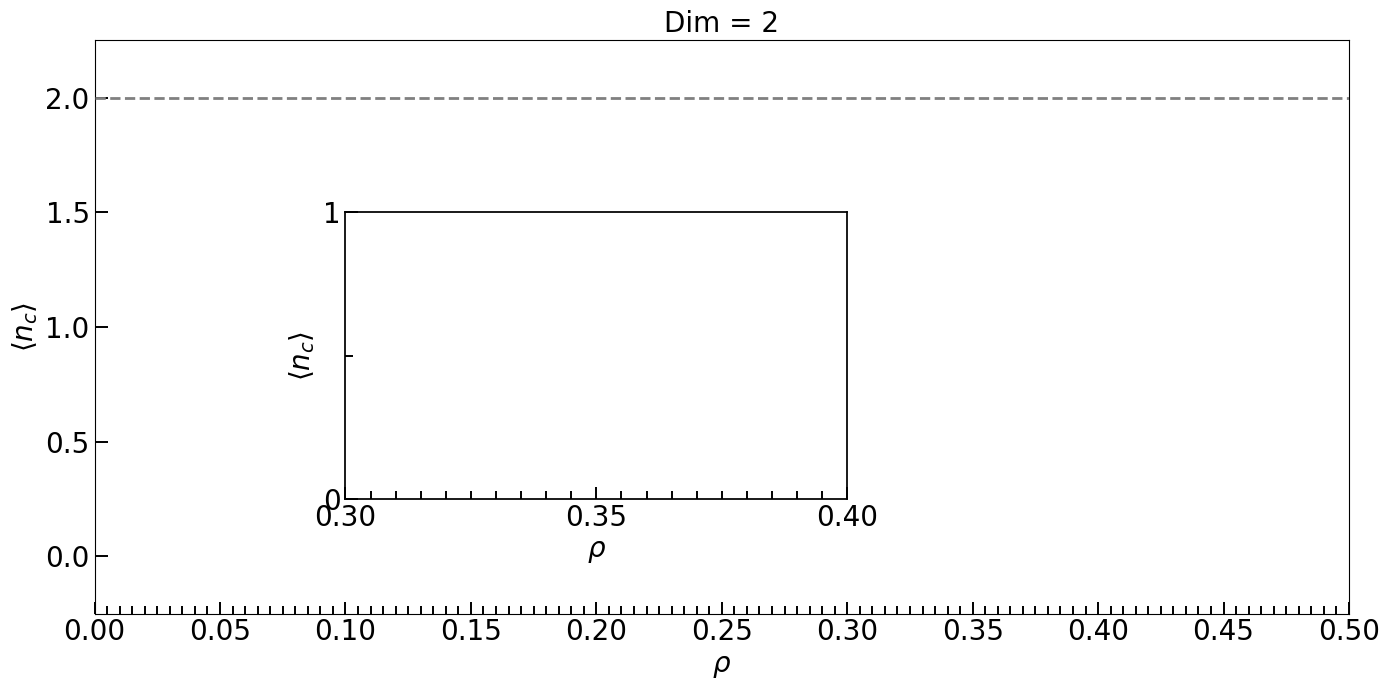

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

# ==== caminho do seu resumo ====
dim = 2
csv_path = f"../Data/bond_percolation/nc_dim_{dim}.csv"

# ==== parâmetros do plot ====
num_colors = 2
rho_max = 1.0 / num_colors  # limitar eixo x

# se quiser filtrar explicitamente, preencha listas; se None, plota tudo que existir no CSV
L_values_filter  = None      # ex.: [512, 1024, 2048]
NT_values_filter = None      # ex.: [50, 100, 200]
k_values_filter  = None      # ex.: [4e-4, 2e-4, 9e-5]

PLOT_ERR = True

# estética
ms = 12
font_tick_size = 20
font_label_size = 20
font_legend_size = 20
colors  = ["red", "purple", "green", "blue", "orange", "teal", "brown", "gray"]
markers = ["o-", "s-", "d-", "^-", "v-", "x-", "P-", "*-"]
mew = 1.4
thickness = 1.4

# ==== funções util ====
def load_nc_summary(path):
    df = pd.read_csv(path)
    required = {"L","n_colors","NT","k","rho","n_c","n_c_err"}
    miss = required - set(df.columns)
    if miss:
        raise ValueError(f"CSV sem colunas {miss}")
    # garantir tipos numéricos
    for c in ["L","NT"]:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")
    for c in ["k","rho","n_c","n_c_err"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def series_nc_vs_rho(df, L, NT, k, rho_max, num_colors):
    sel = df[(df["L"] == L) & (df["NT"] == NT) & (np.isfinite(df["k"]) & np.isclose(df["k"], k)) & (df["n_colors"] == num_colors)]
    if sel.empty:
        return pd.DataFrame(columns=["rho","nc_mean","nc_sem"])
    # limitar rho
    sel = sel[(sel["rho"] >= 0) & (sel["rho"] <= rho_max)]
    if sel.empty:
        return pd.DataFrame(columns=["rho","nc_mean","nc_sem"])
    # agrega por rho (pode haver mais de uma linha por rho)
    grp = sel.groupby("rho", as_index=False).agg(
        nc_mean=("n_c","mean"),
        nc_sem =("n_c_err","mean")   # manter média do SEM reportado
    )
    return grp.sort_values("rho").reset_index(drop=True)

# ==== carregar dados ====
df_nc = load_nc_summary(csv_path)

# aplicar filtros opcionais
df_plot = df_nc.copy()
if L_values_filter is not None:
    df_plot = df_plot[df_plot["L"].isin(L_values_filter)]
if NT_values_filter is not None:
    df_plot = df_plot[df_plot["NT"].isin(NT_values_filter)]
if k_values_filter is not None:
    # cuidado com float: use np.isclose na hora de agrupar/plottar; aqui só reduz valores possíveis
    df_plot = df_plot[np.logical_or.reduce([np.isclose(df_plot["k"], kv) for kv in k_values_filter])]

# descobrir combos existentes
combos = (df_plot[["L","NT","k"]]
          .dropna()
          .drop_duplicates()
          .sort_values(["L","NT","k"])
          .to_records(index=False))

if len(combos) == 0:
    raise RuntimeError("Nenhuma combinação (L, NT, k) encontrada no CSV (ou após filtros).")

# ==== figura ====
fig, ax = plt.subplots(figsize=(14, 7))
ax.xaxis.set_major_locator(MultipleLocator(0.05))
ax.xaxis.set_minor_locator(MultipleLocator(0.005))
ax.set_xlim(0, rho_max)  # <-- limitar eixo x
ax.tick_params(axis='x', which='minor', labelbottom=False)  # sem rótulos nos minor ticks

datasets = []
legend_handles = []

for idx, (L, NT, kval) in enumerate(combos):
    res = series_nc_vs_rho(df_plot, int(L), int(NT), float(kval), rho_max, num_colors)
    if res.empty:
        continue

    fmt   = markers[idx % len(markers)]
    color = colors [idx % len(colors)]

    if PLOT_ERR and "nc_sem" in res.columns and not res["nc_sem"].isna().all():
        h = ax.errorbar(
            res["rho"], res["nc_mean"], yerr=res["nc_sem"],
            fmt=fmt, color=color, linewidth=thickness,
            markersize=ms, markeredgewidth=mew,
            markerfacecolor='none', zorder=2
        )
        marker_char = fmt[0] if fmt else 'o'
    else:
        line, = ax.plot(
            res["rho"], res["nc_mean"], fmt,
            color=color, linewidth=thickness,
            ms=ms, markeredgewidth=mew, markerfacecolor='none', zorder=2
        )
        marker_char = line.get_marker()

    datasets.append((res["rho"].to_numpy(),
                     res["nc_mean"].to_numpy(),
                     marker_char, color))

    legend_handles.append(Line2D(
        [], [], linestyle='None',
        marker=marker_char, markersize=ms,
        markeredgewidth=mew, markerfacecolor='none',
        markeredgecolor=color, color=color,
        label=fr"$L={int(L)}$"
    ))

# ----- inset (zoom) -----
x0, x1 = 0.30, 0.40
x0, x1 = max(0, x0), min(rho_max, x1)

inset_x, inset_y, inset_w, inset_h = 0.2, 0.2, 0.40, 0.50
axins = ax.inset_axes([inset_x, inset_y, inset_w, inset_h], zorder=10)
axins.set_facecolor("white")
axins.grid(False)

ys_zoom = []
for (x, y, marker_char, color) in datasets:
    m = (x >= x0) & (x <= x1)
    if np.any(m):
        axins.plot(x[m], y[m], linestyle='-',
                   marker=marker_char, color=color,
                   linewidth=thickness, ms=max(6, int(ms*0.7)),
                   markeredgewidth=mew, markerfacecolor='none', zorder=11)
        ys_zoom.append(y[m])

axins.set_xlim(x0, x1)

if ys_zoom:
    y_all = np.concatenate(ys_zoom)
    y_all = y_all[np.isfinite(y_all)]
    if y_all.size:
        span = np.ptp(y_all)              # <- usar np.ptp no NumPy 2.0
        pad  = 0.06 * (span if span > 0 else 1.0)
        axins.set_ylim(y_all.min() - pad, y_all.max() + pad)
    else:
        axins.set_ylim(0, 1)
else:
    axins.set_ylim(0, 1)

axins.axhline(y=num_colors, color='gray', linestyle='--', lw=2.0, zorder=100)
axins.xaxis.set_major_locator(MultipleLocator(0.05))
axins.xaxis.set_minor_locator(MultipleLocator(0.005))
axins.yaxis.set_major_locator(MultipleLocator(1.0))
axins.yaxis.set_minor_locator(MultipleLocator(0.5))
axins.tick_params(axis='both', which='major', labelsize=int(font_tick_size), length=9, width=thickness, direction='in')
axins.tick_params(axis='both', which='minor', length=6, width=thickness, direction='in')
axins.set_xlabel(r"$\rho$", fontsize=font_label_size)
axins.set_ylabel(r"$\langle n_c \rangle$", fontsize=font_label_size)
for s in axins.spines.values():
    s.set_linewidth(thickness*0.9)


# ----- eixo principal -----
ax.axhline(y=num_colors, color='gray', linestyle='--', lw=2.0, zorder=100)
ax.set_xlabel(r"$\rho$", fontsize=font_label_size)
ax.set_ylabel(r"$\langle n_c \rangle$", fontsize=font_label_size)
ax.set_ylim([-0.25, num_colors + 0.25])
ax.tick_params(axis='both', which='major', labelsize=font_tick_size, length=9, width=thickness, direction='in')
ax.tick_params(axis='x',   which='minor', length=6, width=thickness, direction='in')

ax.legend(handles=legend_handles, fontsize=font_legend_size, loc="upper right", frameon=False)
ax.set_title("Dim = 2", fontsize=20)
plt.tight_layout()
plt.show()